In [7]:
import os 
import numpy as np
import healpy as hp
import mtneedlet as nl
import sys
import broom

import matplotlib.pyplot as plt
from types import SimpleNamespace
from dataclasses import replace

from broom import (
    Configs,
    get_params,
    component_separation,get_input_data, estimate_residuals, get_nuisance_covariance)
from broom.needlets import _get_needlet_windows_
from broom.clusters import get_mcilc_tracers

root_path = os.path.dirname(os.path.abspath(broom.__file__))


### 📘 Introduction to Configuration Parameters

See `configs/config_demo.yaml` in the broom package and the notebook `tutorial_satellite.ipynb` for a detailed explanation of all parameters.

---

### 🛰️ Tutorial: Simulations Generation

An example of simulations generation is provided in the notebook:  
`tutorial_satellite.ipynb`

In [8]:
# Importing all general parameter from satellite config file

config_path = root_path + "/configs/config_satellite.yaml"

config: Configs = get_params(config_path=config_path)
print("Loaded configuration from\n", config_path)

Loaded configuration from
 /home/alecarones/Post-Doc/tutorial_brooms/broom/configs/config_satellite.yaml


In [3]:
# Generation or loading of input simulations
data = get_input_data(config, nsim = 0)


Generating foreground maps of d1s1 model


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Generating CMB simulation 00000
Generating noise simulation 00000
Generating coadded signal for simulation 00000


## 🔍 Running GILC: Blind Foreground Reconstruction

Perform a **blind reconstruction** of the foreground emission across the observation frequencies using the Generalized Internal Linear Combination (GILC) method.



In [4]:
# Configuration for running GILC.
# It allows to reconstruct foreground emission at the observed frequencies.
# It can be applied also in pixel domain.

config_run = {
    'compsep': [{
    # Method to be applied
    'method': "gilc",
    # Domain in which the method is applied
    'domain': "needlet",
    # Needlet configuration to be used if domain is "needlet"
    'needlet_config':
      [{'needlet_windows': "mexican"},
       {'width': 1.3},
       {'merging_needlets': [0,10,14,17,40]}],
    # Amount of residual ILC bias. It is used to set the size of domain where covariance is computed. 
    # If 0., covariance is computed as the average over the full sky/patch.
    'ilc_bias': 0.05,
    # If True, needlet bands are squared. Therefore needlet transformation is performed just once 
    # before component separation. 
    'b_squared': False,
    # If True, the HEALPix resolution of needlet maps is adapted to the sampled range of multipoles.    
    'adapt_nside': True,
    # List of components to be included in the nuisance covariance matrix. 
    # Each component is expressed as a string. It can be "cmb", "noise" or any PySM model acronymn (e.g. "cib1",...).
    # The covariance of this components is loaded from disk if 'load_nuisance_covariance' is True, otherwise it is computed from the input data.
    # If loaded from disk, the user need to run BROOM 'get_nuisance_covariance' function before running GILC, 
    # to save the covariance of the selected components in the specific method path (see cell below).
    # If 'load_nuisance_covariance' is False, the provided input data needs to have the selected components as attributes (e.g. data.cmb, data.noise, data.cib).
   'nuisance': ["cmb", "noise"],
    # If not null in some elements, it will set a deprojection coefficient 
    # for the CMB in the correppsonding needlet band, i.e. cmb_residuals = depro_cmb * cmb_input in output foreground maps.
    # If None (default), no constraints will be set.
    'depro_cmb': None, #[None, None, None], #[None,0.,0.,0.]
    # If not zero, it will include 'm_bias' more (if m_bias > 0) 
    # or less (if m_bias < 0) modes in the reconstructed GILC maps. Default is 0.
    # It can be a list if different values are needed for different needlet bands.
    # If e.g. m_bias > 0, foreground signal will be better reconstructed at the price of higher noise and CMB residues.
    'm_bias': 0, #[0,0,0,0],
    # List of indices of frequency channels you want to reconstruct with GNILC. 
    # If not provided, all channels are reconstructed.
    'channels_out': [i for i in range(len(config.instrument.frequency))],
    # If True, needlet bands are saved in the specific method path.  
    'save_needlets': False,
    # If different from 0. it will debias the covariance matrix by a factor cov_noise_debias * noise_covariance.
    # If float, it will be applied to all needlet bands.
    # If a list, each element will be applied to corresponding needlet band.
    # Default = 0. for all needlet bands
    'cov_noise_debias': 0., #[0.,0.,0.,0.],
    'save_weights': True,
    'load_nuisance_covariance': False,
}]}

config.config["compsep"] = config_run["compsep"]
config.config["field_out"] = "B"
config._store_passed_settings()   # refresh all dependent attributes

# data.nuisance = data.cmb + data.noise
outputs_gilc = component_separation(config, data, nsim = 0)


Pre-processing input alms for component separation for simulation 00000.
Bringing inputs to common resolution
Correcting for input pixel window function
Running component separation for simulation 00000.
Running gilc in needlet domain for simulation 00000.


/home/alecarones/Post-Doc/tutorial_brooms/broom/inputs.py:595: RuntimeWarning: divide by zero encountered in divide
  pixwin_inv = 1. / np.array(hp.pixwin(config.nside_in, pol=True, lmax=config.lmax))


Size of the outputs is (1, 22, 49152)


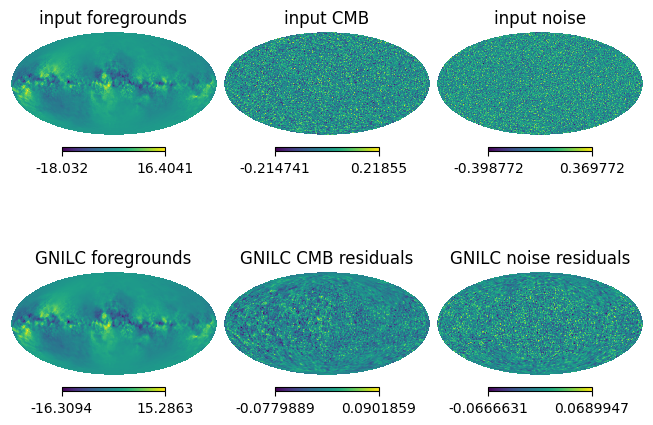

In [25]:
# Let's compare input and GILC reconstructed foreground emission

# Shape is (n_cases, n_channels, (n_fields_out), n_pixels)
print(f'Size of the outputs is {np.array(outputs_gilc.total).shape}')

idx_field = {"T": 0, "E": 1, "B": 2}

freq_idx = 12
field = idx_field[config.field_out]

# data_type is "alms" - inputs
fgds = hp.alm2map(data.fgds[freq_idx,field],config.nside,lmax=config.lmax_in)
noise = hp.alm2map(data.noise[freq_idx,field],config.nside,lmax=config.lmax_in)
cmb = hp.alm2map(data.cmb[freq_idx,field],config.nside,lmax=config.lmax_in)

plt.figure()
# inputs
hp.mollview(fgds, title="input foregrounds", sub=(2,3,1))
hp.mollview(cmb, title="input CMB", sub=(2,3,2))
hp.mollview(noise, title="input noise", sub=(2,3,3))
# GNILC outputs
hp.mollview(outputs_gilc.fgds[0][freq_idx], title="GNILC foregrounds", sub=(2,3,4))
hp.mollview(outputs_gilc.cmb[0][freq_idx], title="GNILC CMB residuals", sub=(2,3,5))
hp.mollview(outputs_gilc.noise[0][freq_idx], title="GNILC noise residuals", sub=(2,3,6))


#### In real world scenario the nuisance covariance needs to be computed from simulations or data-splits difference

In [31]:
# One option is therefore to pass as data.nuisance the data difference.
# In this simplified case, we pass as nuisance kust the sum of components we want as nuisance
# and include "nuisance" in nuisance list in the GILC configuration above.

data.nuisance = data.cmb + data.noise

config_run = {
    'compsep': [{
    'method': "gilc",
    'domain': "needlet",
    'needlet_config':
      [{'needlet_windows': "mexican"},
       {'width': 1.3},
       {'merging_needlets': [0,10,14,17,40]}],
    'ilc_bias': 0.05,
    'b_squared': False,
    'adapt_nside': True,
    'nuisance': ["nuisance"],
    'depro_cmb': None,
    'm_bias': 0,
    'channels_out': [i for i in range(len(config.instrument.frequency))],
    'save_needlets': False,
    'cov_noise_debias': 0.,
    'save_weights': True,
}]}

config.config["compsep"] = config_run["compsep"]
config.config["field_out"] = "B"
config._store_passed_settings()   # refresh all dependent attributes

outputs_gilc = component_separation(config, data, nsim = 0)

Pre-processing input alms for component separation for simulation 00000.
Bringing inputs to common resolution
Correcting for input pixel window function
Running component separation for simulation 00000.
Running gilc in needlet domain for simulation 00000.


/home/alecarones/Post-Doc/tutorial_brooms/broom/inputs.py:595: RuntimeWarning: divide by zero encountered in divide
  pixwin_inv = 1. / np.array(hp.pixwin(config.nside_in, pol=True, lmax=config.lmax))
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [d

In [11]:
# We can also estimate the nuisance covariance from simulations and then load it in the GILC run by setting 'load_nuisance_covariance' to True in the GILC configuration above.

# In order to estimate and save nuisance covariance, we need to set up the 'nuisance_covariance' dictionary in the configuration file.
config_run = {
    'nuisance_covariance': [{
    # Type of covariance to be estimated. It can be "scalar", 
    # "P_scalar" (for GPILC application in polarization, see below) or "Pr_scalar" (for estimation of C+ term). See BROOM paper for details.
    'type': "scalar",
    # Domain for covariance estimation. This and 'needlet_config' should match those used in the GILC run.
    'domain': "needlet",
    'needlet_config':
       [{'needlet_windows': "mexican"},
        {'width': 1.3},
       {'merging_needlets': [0,10,14,17,40]}],
    # ilc_bias should match GILC parameter as well.
    'ilc_bias': 0.05,
    'b_squared': False,
    'adapt_nside': True,
    'nuisance': ["noise", "cmb"],
    'save_needlets': True,
}]}

config.config["nuisance_covariance"] = config_run["nuisance_covariance"]
config._store_passed_settings()   # refresh all dependent attributes

# It will use 10 simulations generated on the fly to estimate nuisance covariance
# Optionally, one can provide 'nuisance_path' parameter to set the path where input nuisance
#     components will be loaded.

# This will set the starting simulationa and number of simulations to be used for covariance estimation.
config.config["nsim_start"] = 0
config.config["nsims"] = 10
config._store_passed_settings()   

get_nuisance_covariance(config), # nuisance_path = nuis_path)


Generating CMB simulation 00000
Generating noise simulation 00000
Bringing inputs to common resolution
Correcting for input pixel window function
Generating CMB simulation 00001
Generating noise simulation 00001
Bringing inputs to common resolution
Correcting for input pixel window function
Generating CMB simulation 00002
Generating noise simulation 00002
Bringing inputs to common resolution
Correcting for input pixel window function
Generating CMB simulation 00003
Generating noise simulation 00003
Bringing inputs to common resolution
Correcting for input pixel window function
Generating CMB simulation 00004
Generating noise simulation 00004
Bringing inputs to common resolution
Correcting for input pixel window function
Generating CMB simulation 00005
Generating noise simulation 00005
Bringing inputs to common resolution
Correcting for input pixel window function
Generating CMB simulation 00006
Generating noise simulation 00006
Bringing inputs to common resolution
Correcting for input 

(None,)

In [12]:
# If you want to add more simulations to the covariance estimation, 
# you can just rerun for the desired number 'nsims' and will update stored covariance.
# In this case, in the end it will be estimated from 15 simulations.
config.config["nsim_start"] = 0
config.config["nsims"] = 5
config._store_passed_settings()

get_nuisance_covariance(config)

Generating CMB simulation 00000
Generating noise simulation 00000
Bringing inputs to common resolution
Correcting for input pixel window function


/home/alecarones/Post-Doc/tutorial_brooms/broom/inputs.py:595: RuntimeWarning: divide by zero encountered in divide
  pixwin_inv = 1. / np.array(hp.pixwin(config.nside_in, pol=True, lmax=config.lmax))


Generating CMB simulation 00001
Generating noise simulation 00001
Bringing inputs to common resolution
Correcting for input pixel window function
Generating CMB simulation 00002
Generating noise simulation 00002
Bringing inputs to common resolution
Correcting for input pixel window function
Generating CMB simulation 00003
Generating noise simulation 00003
Bringing inputs to common resolution
Correcting for input pixel window function
Generating CMB simulation 00004
Generating noise simulation 00004
Bringing inputs to common resolution
Correcting for input pixel window function


In [14]:
# Printing content of the path where covariances are stored.

path = os.path.join(config.path_outputs, "nuisance_covariances_needlet_bias0.05/mexican_B1.3_j0j9_j10j13_j14j16_j17j39")

for filename in os.listdir(path):
    print(filename)

cmb+noise_covariance_B_70.5acm_ns64_lmax150_nl3_15sims.npy
cmb+noise_covariance_B_70.5acm_ns64_lmax150_nl1_15sims.npy
cmb+noise_covariance_B_70.5acm_ns32_lmax150_nl0_15sims.npy
cmb+noise_covariance_B_70.5acm_ns64_lmax150_nl2_15sims.npy
needlet_bands.npy


In [34]:
# And then to load the computed nuisance covariance we set 'load_nuisance_covariance' to True in the GILC configuration below
#  and include the same components in the 'nuisance' list.

config_run = {
    'compsep': [{
    # Method to be applied
    'method': "gilc",
    # Domain in which the method is applied
    'domain': "needlet",
    # Needlet configuration to be used if domain is "needlet"
    'needlet_config':
      [{'needlet_windows': "mexican"},
       {'width': 1.3},
       {'merging_needlets': [0,10,14,17,40]}],
    'ilc_bias': 0.05,
    'b_squared': False,
    'adapt_nside': True,
    'nuisance': ["cmb", "noise"],
    'depro_cmb': None, #[None, None, None], #[None,0.,0.,0.]
    'm_bias': 0, #[0,0,0,0],
    'channels_out': [i for i in range(len(config.instrument.frequency))],
    'save_needlets': False,
    'cov_noise_debias': 0., #[0.,0.,0.,0.],
    'save_weights': True,
    'load_nuisance_covariance': True,
}]}

config.config["compsep"] = config_run["compsep"]
config.config["field_out"] = "B"
config._store_passed_settings()   # refresh all dependent attributes

# data.nuisance = data.cmb + data.noise
outputs_gilc = component_separation(config, data, nsim = 0)


Pre-processing input alms for component separation for simulation 00000.
Bringing inputs to common resolution
Correcting for input pixel window function
Running component separation for simulation 00000.
Running gilc in needlet domain for simulation 00000.


/home/alecarones/Post-Doc/tutorial_brooms/broom/inputs.py:595: RuntimeWarning: divide by zero encountered in divide
  pixwin_inv = 1. / np.array(hp.pixwin(config.nside_in, pol=True, lmax=config.lmax))
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [d

Size of the outputs is (1, 22, 49152)


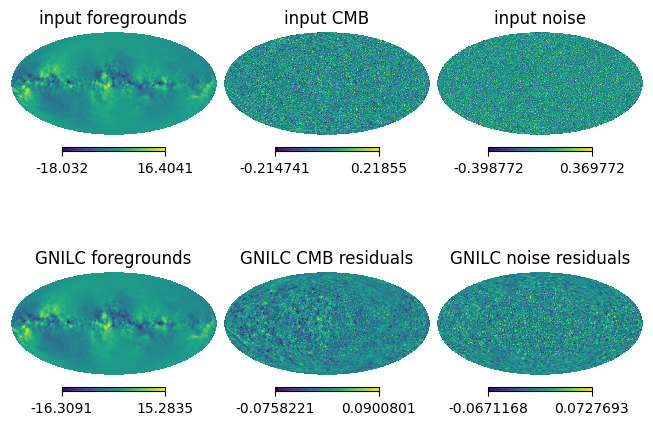

In [35]:
# Let's compare input and GILC reconstructed foreground emission

# Shape is (n_cases, n_channels, (n_fields_out), n_pixels)
print(f'Size of the outputs is {np.array(outputs_gilc.total).shape}')

idx_field = {"T": 0, "E": 1, "B": 2}

freq_idx = 12
field = idx_field[config.field_out]

# data_type is "alms" - inputs
fgds = hp.alm2map(data.fgds[freq_idx,field],config.nside,lmax=config.lmax_in)
noise = hp.alm2map(data.noise[freq_idx,field],config.nside,lmax=config.lmax_in)
cmb = hp.alm2map(data.cmb[freq_idx,field],config.nside,lmax=config.lmax_in)

plt.figure()
# inputs
hp.mollview(fgds, title="input foregrounds", sub=(2,3,1))
hp.mollview(cmb, title="input CMB", sub=(2,3,2))
hp.mollview(noise, title="input noise", sub=(2,3,3))
# GNILC outputs
hp.mollview(outputs_gilc.fgds[0][freq_idx], title="GNILC foregrounds", sub=(2,3,4))
hp.mollview(outputs_gilc.cmb[0][freq_idx], title="GNILC CMB residuals", sub=(2,3,5))
hp.mollview(outputs_gilc.noise[0][freq_idx], title="GNILC noise residuals", sub=(2,3,6))


## 🌌 Estimate Foreground Residuals

### The GNILC templates generated in the previous step can be employed to estimate blindly foreground residuals in the component-separated CMB map.


In [26]:
# Let's perform a NILC run (details in tutorial_satellite.ipynb)

# NILC weights need to be saved in order to then estimate the corresponding fgds residuals (save_weights=True)
# These weights are used to combine the GILC estimated foreground emission at the different frequency channels 
# This step requires GILC maps to be saved for all frequency channels.

config_run = {
    'compsep': [{'method': "ilc", 'domain': "needlet", 'ilc_bias': 0.001,
    'needlet_config':
      [{'needlet_windows': "mexican"},
       {'width': 1.3},
       {'merging_needlets': [0, 14, 17, 19, 40]}],
    'adapt_nside': True, 'save_needlets': True, 'save_weights': True,
}]}

config.config["compsep"] = config_run["compsep"]
config.config["field_out"] = "B"
config._store_passed_settings()   # refresh all dependent attributes

outputs_nilc = component_separation(config, data, nsim = 0)


Pre-processing input alms for component separation for simulation 00000.
Bringing inputs to common resolution
Correcting for input pixel window function
Running component separation for simulation 00000.
Running ilc in needlet domain for simulation 00000.


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


In [27]:
# To estimate foreground residuals from compsep we need to set up the 'compsep_residuals' dictionary

# GILC inputs can either be loaded from disk by setting the 'gilc_path' key.

config_res_run = {
    'compsep_residuals': [{
    # Specific path to GILC foreground maps to be used as foreground templates.
    # It will be added to config.path_outputs to generate the full path
    'gilc_path': "gilc_needlet_bias0.05_nuis_cmb+noise/mexican_B1.3_j0j9_j10j13_j14j16_j17j39", 
    # Components save in GNILC compsep which will be propagated with compsep weights.
    # The only required component is "output_total".
    # Also "noise_residuals" can be useful to debias the angular power spectrum of the estimated foreground residuals.
    'gilc_components': ["output_total","noise_residuals"],
    # Method-specific path where compsep weights are stored and for which fgd residuals are estimated.
    # It will be added to config.path_outputs to generate the full path
    # This correspond to the one run above.
    'compsep_path': "ilc_needlet_bias0.001/mexican_B1.3_j0j13_j14j16_j17j18_j19j39/cmb_reconstruction",
    # If True, adapt the GNILC foreground emission maps to proper resolution considering sampled multipoles
    # by each needlet band
    'adapt_nside': True,
    # This parameter can be used to specify the field(s) of the GNILC maps which are passed or to be loaded from disk. 
    # By default, it is set to config.field_out.
    'field_in': "B",
}]}

config.config["compsep_residuals"] = config_res_run["compsep_residuals"]
config._store_passed_settings()   #

outputs_res = estimate_residuals(config, nsim=0)

Running foregrounds residuals estimation for simulation 00000.
Inputs are assumed to be at common angular resolution
Correcting for input pixel window function


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


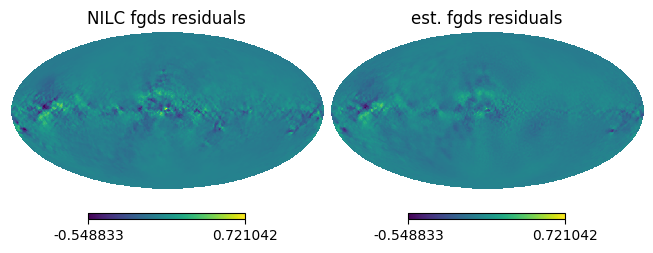

In [28]:
plt.figure()
hp.mollview(outputs_nilc.fgds[0], title="NILC fgds residuals", sub=(1,2,1),min=np.min(outputs_nilc.fgds[0]),max=np.max(outputs_nilc.fgds[0]))
hp.mollview(outputs_res.total[0], title="est. fgds residuals", sub=(1,2,2),min=np.min(outputs_nilc.fgds[0]),max=np.max(outputs_nilc.fgds[0]))


In [29]:
# GILC inputs can also be passed directly as output of the GILC run above by passing them to the 'estimate_residuals' function.

config_res_run = {
    'compsep_residuals': [{
    'gilc_components': ["output_total","noise_residuals"],
    'compsep_path': "ilc_needlet_bias0.001/mexican_B1.3_j0j13_j14j16_j17j18_j19j39/cmb_reconstruction",
    'adapt_nside': True,
    'field_in': "B",
}]}

config.config["compsep_residuals"] = config_res_run["compsep_residuals"]
config._store_passed_settings()   #

outputs_res = estimate_residuals(config, nsim=0, gilc_outputs=outputs_gilc)

Running foregrounds residuals estimation for simulation 00000.


## 🧪 Diagnosing Foreground Complexity

Perform diagnostics of **foreground complexity**. It provides the number of independent modes which constitute the observed foreground emission at each pixel.

(see [arXiv:2402.17579](https://arxiv.org/abs/2402.17579) for detailed methodology).

In [4]:
# Configuration for foreground diagnostic of scalar fields detected by a given experiment
# In this case, we consider only B-modes as config.field_out is set to 'B', but can be used for all scalar fields.

config_run = {
    'compsep': [{
    # Method to be applied
    'method': "fgd_diagnostic",
    # Domain in which the method is applied
    'domain': "needlet",
    # Needlet configuration to be used if domain is "needlet"
    'needlet_config':
      [{'needlet_windows': "mexican"},
       {'width': 1.3},
       {'merging_needlets': [0,10,14,17,40]}],
    # It sets the size of domains where covariance is computed. 
    # If 0. (default), covariance is computed as the average over the full sky/patch and
    # it will return a single value of fgd complexity across the sky
    'ilc_bias': 0.1,
    # If True, needlet bands are squared. 
    'b_squared': False,
    # If True, the HEALPix resolution of needlet maps is adapted to the sampled range of multipoles.    
    'adapt_nside': False,
    # As in GILC, it is possible to set the components to be included in the nuisance covariance matrix.
    'nuisance': ["noise", "cmb"],
    # If True, needlet bands are saved in the method specific path.  
    'save_needlets': True,
    'cov_noise_debias': [0.,0.,0.,0.],
    # As in GILC, it is possible to specify if the nuisance covariance is loaded from disk or estimated from the input data.
    'load_nuisance_covariance': False,
    # As in GILC, it is possible to specify if noise covariance is loaded from disk,
    # if any element in 'cov_noise_debias' is different from 0.
    'load_noise_covariance': False,

}]}

config.config["compsep"] = config_run["compsep"]
config._store_passed_settings()   # refresh all dependent attributes

diagnostic_maps = component_separation(config, data, nsim = 0)


Pre-processing input alms for component separation for simulation 00000.
Bringing inputs to common resolution
Correcting for input pixel window function
Running component separation for simulation 00000.
Running fgd_diagnostic in needlet domain for simulation 00000.


/home/alecarones/Post-Doc/tutorial_brooms/broom/inputs.py:595: RuntimeWarning: divide by zero encountered in divide
  pixwin_inv = 1. / np.array(hp.pixwin(config.nside_in, pol=True, lmax=config.lmax))
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


In [5]:
print(f'Attributes of "diagnostic_maps" are {", ".join(vars(diagnostic_maps).keys())}')

print(f"'m' shape is {np.array(diagnostic_maps.m).shape}")

Attributes of "diagnostic_maps" are m
'm' shape is (1, 4, 49152)


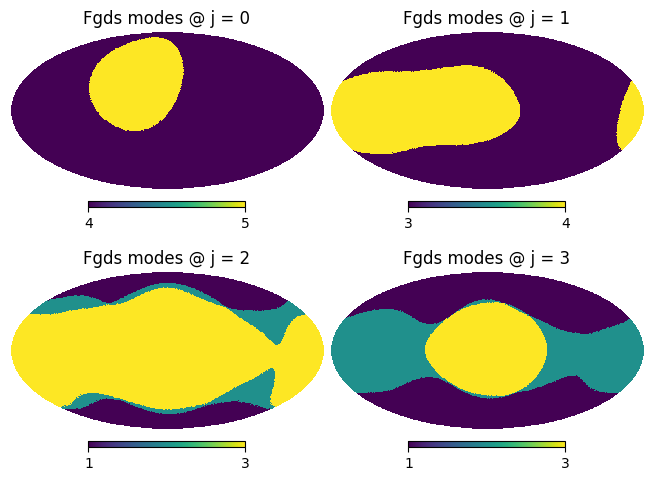

In [6]:
plt.figure()
# inputs
for k in range(np.array(diagnostic_maps.m).shape[1]):
    hp.mollview(diagnostic_maps.m[0][k], title=f"Fgds modes @ j = {k}", sub=(2,2,k+1))


In [8]:
64 // 4

16

## Extension to Polarization Intensity

As shown in [`tutorial_satellite.ipynb`](./tutorial_satellite.ipynb),  
the methodologies described above can also be applied to **polarization intensity**.

The procedure to **estimate of foreground residuals** is analogous to the case presented above (you are not forced to used GPILC templates), the compsep_path should only be adapted accordingly

In [12]:
# GPILC run
# We note that GP(R)ILC at the moment is only implemented with real weights.
# Therefore the nuisance and/or noise covariance to be generated (optionally) with get_nuisance_covariance for the GPILC runs needs to be the C+.
# This is obtained by setting 'type' to "Pr_scalar" in the 'nuisance_covariance' configuration.

config_run = {
    'compsep': [{
    'method': "gpilc", # or "gprilc" for weight with no imaginary part
    'domain': "needlet",
    'needlet_config':
      [{'needlet_windows': "mexican"},
       {'width': 1.3},
       {'merging_needlets': [0,10,14,17,40]}],
    'ilc_bias': 0.01,
    'nuisance': ["cmb", "noise"],
    'depro_cmb': [None, None, None], #[None,0.,0.,0.]
    'm_bias': [0,0,0,0],
    'channels_out': [i for i in range(len(config.instrument.frequency))],
    'save_needlets': False,
    'load_nuisance_covariance': False,
    'load_noise_covariance': False,
    },

# FGD diagnostic in Polarization intensity
# The same as for GPILC: at the moment diagnostic for polarization intensity is implemented just considering C+.
# Therefore nuisance covariance to be generated (optionally) with get_nuisance_covariance for the FGD runs needs to be the C+.
# This is obtained by setting 'type' to "Pr_scalar" in the 'nuisance_covariance' configuration.
    {
    'method': "fgd_P_diagnostic", # 
    'domain': "needlet",
    'needlet_config':
      [{'needlet_windows': "mexican"},
       {'width': 1.3},
       {'merging_needlets': [0,10,14,17,40]}],
    'ilc_bias': 0.1,
    'nuisance': ["cmb", "noise"],
    'save_needlets': False,
}]}

config.config["compsep"] = config_run["compsep"]
config._store_passed_settings()   # refresh all dependent attributes

outputs_pi = component_separation(config, data, nsim = 0)


Pre-processing input alms for component separation for simulation 00000.
Bringing inputs to common resolution
Correcting for input pixel window function
Running component separation for simulation 00000.
Running gpilc in needlet domain for simulation 00000.
No nuisance alms provided. Using input noise and CMB alms as nuisance.


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to

Running fgd_P_diagnostic in needlet domain for simulation 00000.
No nuisance alms provided. Using input noise and CMB alms as nuisance.


setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
